Epoch 1/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 102s 132ms/step - accuracy: 0.7273 - loss: 0.5283 - val_accuracy: 0.9373 - val_loss: 0.1813 - learning_rate: 1.0000e-04
Epoch 2/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 96s 131ms/step - accuracy: 0.9628 - loss: 0.1242 - val_accuracy: 0.9538 - val_loss: 0.1435 - learning_rate: 1.0000e-04
Epoch 3/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 96s 131ms/step - accuracy: 0.9811 - loss: 0.0661 - val_accuracy: 0.9644 - val_loss: 0.1209 - learning_rate: 1.0000e-04
Epoch 4/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 96s 131ms/step - accuracy: 0.9841 - loss: 0.0559 - val_accuracy: 0.9800 - val_loss: 0.0706 - learning_rate: 1.0000e-04
Epoch 5/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 96s 131ms/step - accuracy: 0.9869 - loss: 0.0450 - val_accuracy: 0.9717 - val_loss: 0.0946 - learning_rate: 1.0000e-04
Epoch 6/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9871 - loss: 0.0430
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
732/732 ━━━━━━━━━━━━━━━━━━━━ 96s 131ms/s

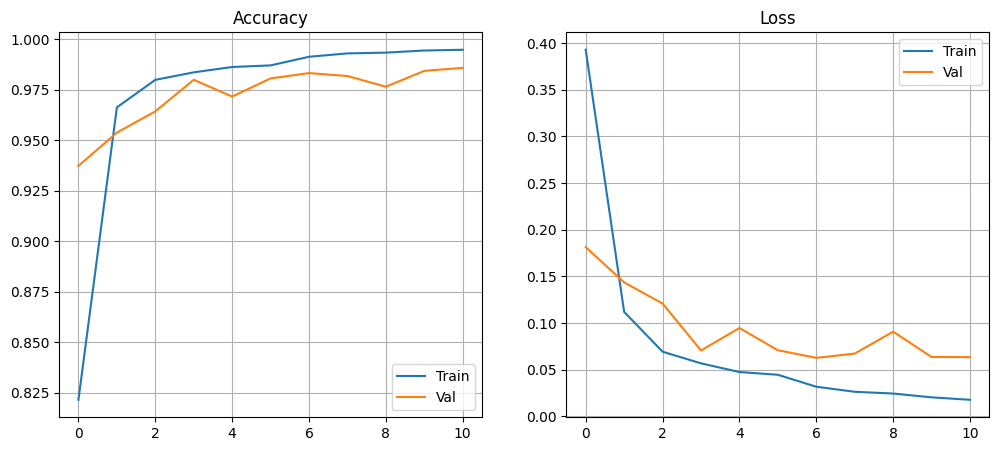

457/457 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step


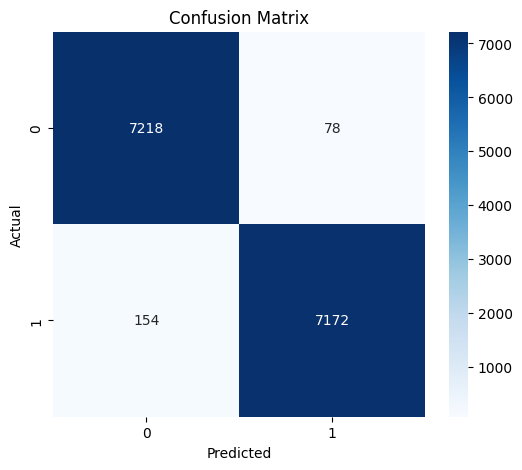


 Model Performance Summary:

      Metric     Value
0   Accuracy  0.984133
1  Precision  0.989241
2     Recall  0.978979
3   F1 Score  0.984083
4        AUC  0.995796
5      AUPRC  0.993861
6        MCC  0.968320
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step


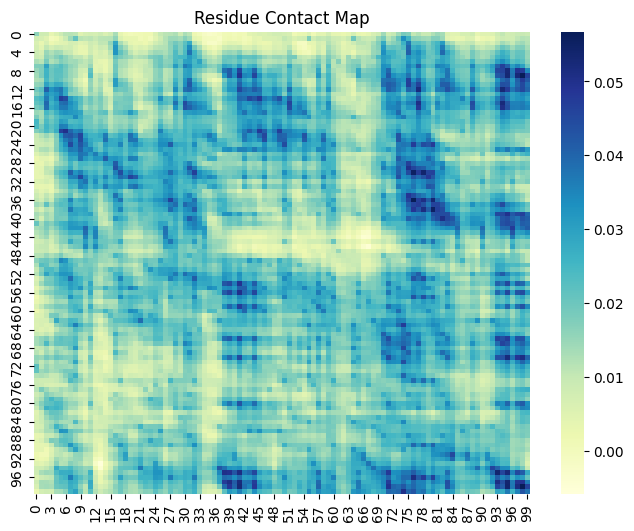

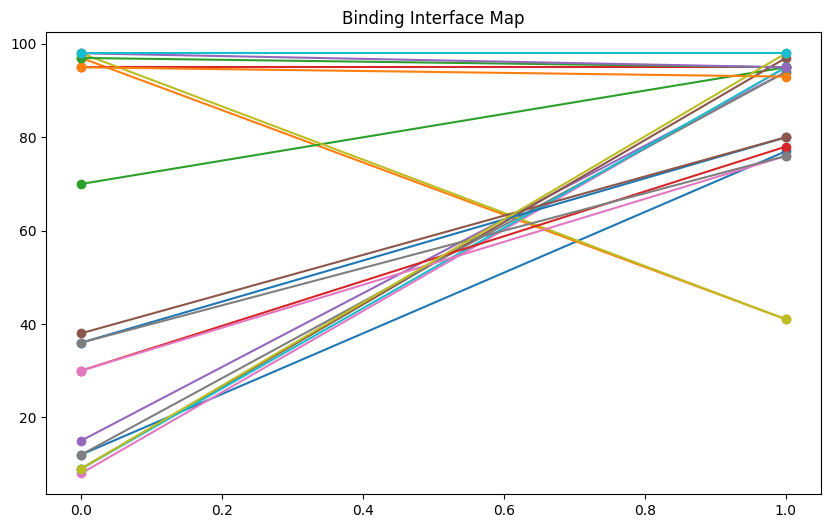

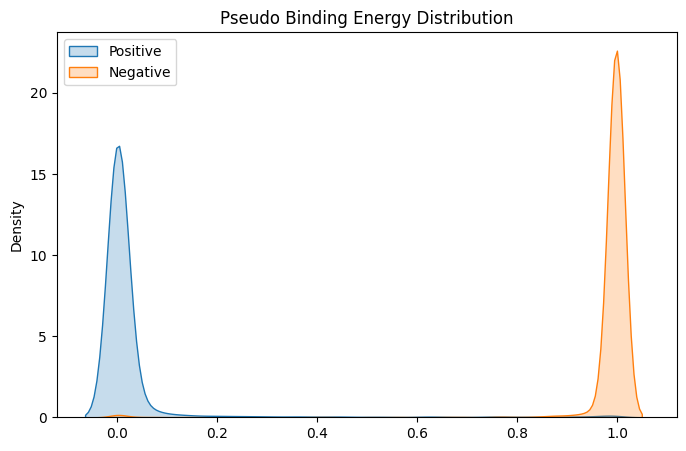

In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D,
    Bidirectional, LSTM, Dense, Dropout,
    Concatenate, GlobalMaxPooling1D, GlobalAveragePooling1D,
    BatchNormalization
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, matthews_corrcoef,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Feature Extraction & Data Loading

def extract_aac_features(sequences):
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    features = []
    for seq in sequences:
        seq = str(seq).upper()
        # Added check to prevent division by zero
        length = len(seq) if len(seq) > 0 else 1
        counts = [seq.count(aa) / length for aa in amino_acids]
        features.append(counts)
    return np.array(features)

# Load data (Assuming paths are correct for your environment)
# Note: Using try/except or ensuring files exist is good practice
pos_df = pd.read_csv("/kaggle/input/datasets/spandansureja/ppi-dataset/positive_protein_sequences.csv").iloc[:, :2]
neg_df = pd.read_csv("/kaggle/input/datasets/spandansureja/ppi-dataset/negative_protein_sequences.csv").iloc[:, :2]

pos_df.columns = ["p1", "p2"]
neg_df.columns = ["p1", "p2"]
pos_df["label"] = 1
neg_df["label"] = 0

df = pd.concat([pos_df, neg_df], ignore_index=True).sample(frac=1, random_state=42)

# Encoding sequences
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
aa_to_int = {aa: i+1 for i, aa in enumerate(amino_acids)}

def encode(seq):
    return [aa_to_int.get(aa, 0) for aa in str(seq).upper()]

MAX_LEN = 500

X1_seq = pad_sequences(df["p1"].apply(encode), maxlen=MAX_LEN, padding="post")
X2_seq = pad_sequences(df["p2"].apply(encode), maxlen=MAX_LEN, padding="post")
X1_aac = extract_aac_features(df["p1"])
X2_aac = extract_aac_features(df["p2"])
y = df["label"].values

# Split: Using 20% for test, and we will use a 20% validation split in .fit()
(X1_s_tr, X1_s_ts, X2_s_tr, X2_s_ts,
 X1_a_tr, X1_a_ts, X2_a_tr, X2_a_ts,
 y_train, y_test) = train_test_split(
    X1_seq, X2_seq, X1_aac, X2_aac, y,
    test_size=0.2, random_state=42, stratify=y
)


# 2. Model Architecture

def multi_kernel_block(x):
    b3 = Conv1D(64, 3, padding="same", activation="relu")(x)
    b5 = Conv1D(64, 5, padding="same", activation="relu")(x)
    b7 = Conv1D(64, 7, padding="same", activation="relu")(x)
    m = Concatenate()([b3, b5, b7])
    return Concatenate()([GlobalAveragePooling1D()(m), GlobalMaxPooling1D()(m)])

in1_seq = Input(shape=(MAX_LEN,))
in2_seq = Input(shape=(MAX_LEN,))
in1_aac = Input(shape=(20,))
in2_aac = Input(shape=(20,))

emb = Embedding(input_dim=21, output_dim=128)
lstm = Bidirectional(LSTM(64, return_sequences=True))

def protein_branch(seq_in, aac_in):
    x = emb(seq_in)
    x = lstm(x)
    residue_features = x
    x = multi_kernel_block(x)
    fused = Concatenate()([x, aac_in])
    fused = Dense(128, activation="relu")(fused)
    fused = BatchNormalization()(fused)
    return fused, residue_features

(b1, f1) = protein_branch(in1_seq, in1_aac)
(b2, f2) = protein_branch(in2_seq, in2_aac)

merged = Concatenate()([b1, b2])
dense = Dense(256, activation="relu")(merged)
dense = Dropout(0.5)(dense)
out = Dense(1, activation="sigmoid")(dense)

model = Model(inputs=[in1_seq, in2_seq, in1_aac, in2_aac], outputs=out)

# FIX: Lower learning rate for stability
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

# Callbacks to handle training dynamics
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
]


# 3. Training

history = model.fit(
    [X1_s_tr, X2_s_tr, X1_a_tr, X2_a_tr],
    y_train,
    epochs=20, # Increased epochs because LR is lower
    batch_size=64,
    validation_split=0.2, # Increased split for stability
    callbacks=callbacks,
    verbose=1
)


# 4. Training Curves

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend(); plt.grid()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend(); plt.grid()
plt.show()


# 5. Predictions

y_prob = model.predict([X1_s_ts, X2_s_ts, X1_a_ts, X2_a_ts])
y_pred = (y_prob > 0.5).astype(int)


# 6. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 7. Metrics Calculation

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
auprc = average_precision_score(y_test, y_prob)
mcc = matthews_corrcoef(y_test, y_pred)


# 8. Metrics Table

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "AUC", "AUPRC", "MCC"],
    "Value": [accuracy, precision, recall, f1, auc, auprc, mcc]
})

print("\n Model Performance Summary:\n")
print(metrics_df)


# 9. Residue-Level Contact Map 

idx = np.where((y_test == 1) & (y_prob.flatten() > 0.8))[0][0]

feat1, feat2, prob = feature_extractor.predict(
    [X1_s_ts[idx:idx+1], X2_s_ts[idx:idx+1],
     X1_a_ts[idx:idx+1], X2_a_ts[idx:idx+1]]
)

N_RES = 100
contact_map = np.matmul(feat1[0, :N_RES, :], feat2[0, :N_RES, :].T)

plt.figure(figsize=(8,6))
sns.heatmap(contact_map, cmap="YlGnBu")
plt.title("Residue Contact Map")
plt.show()


# 10. Binding Interface Map

plt.figure(figsize=(10,6))

top_k = 20
flat_idx = np.argsort(contact_map.flatten())[-top_k:]
rows, cols = np.unravel_index(flat_idx, contact_map.shape)

for r, c in zip(rows, cols):
    plt.plot([0,1],[r,c], marker='o')

plt.title("Binding Interface Map")
plt.show()


# 11. Energy Distribution Plot

energies = 1 - y_prob.flatten()

plt.figure(figsize=(8,5))
sns.kdeplot(energies[y_test == 1], fill=True, label='Positive')
sns.kdeplot(energies[y_test == 0], fill=True, label='Negative')
plt.title("Pseudo Binding Energy Distribution")
plt.legend()
plt.show()